Grupo 5:

1. Eric Arjona
2. Francisco Molina
3. Maximiliano Vindel

En el presente análisis de exploración de datos, se carga un mes de solicitudes aprobadas con los programas de vivienda. El presente análisis de dato tiene un alcance de evaluación de estadística descriptiva e histrogramas generados.

In [3]:
import pandas as pd

In [4]:
url = 'https://raw.githubusercontent.com/MaximilianoVE/Grupo_5_Proyecto_social-/refs/heads/main/datos_info/diccionario_datos.csv'

data = pd.read_csv(url)

In [5]:
#Conocer como se mira la data.

data

,ingreso_$,endeudamiento,prestamo_$,programa,plazo
0,1100,47.35,48148,Clase social,360
1,833,37.98,48148,Clase social,360
2,815,31.22,37037,Clase media,360
3,1111,37.98,48145,Clase social,360
4,847,47.35,43253,Clase social,360
...,...,...,...,...,...
159,1167,28.88,48148,Clase media,360
160,1845,40.50,98939,Clase media,360
161,1291,47.99,55333,Clase media,360
162,2472,44.99,148072,Clase media,360


In [6]:
#Conocer cuantas filas y columnas tiene el dataframe.

data.shape

(164, 5)

In [7]:
#Conocer que tipo de datos tiene la data, en este caso, la unica variable que no es numerica es "programa".

data.dtypes

,0
ingreso_$,int64
endeudamiento,float64
prestamo_$,int64
programa,object
plazo,int64


In [8]:
#Saber que tan completa es la información del dataframe.

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ingreso_$      164 non-null    int64  
 1   endeudamiento  164 non-null    float64
 2   prestamo_$     164 non-null    int64  
 3   programa       164 non-null    object 
 4   plazo          164 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 6.5+ KB


In [9]:
#Conocer estadística descriptiva de la base de datos.

data.describe()

,ingreso_$,endeudamiento,prestamo_$,plazo
count,164.000000,164.000000,164.000000,164.000000
mean,1601.506098,42.814085,70109.310976,349.146341
std,1048.144943,14.683405,34532.716984,31.235351
min,657.000000,21.050000,37037.000000,180.000000
25%,947.500000,33.117500,48148.000000,360.000000
50%,1175.000000,41.010000,48148.000000,360.000000
75%,1761.250000,48.745000,85226.500000,360.000000
max,6302.000000,115.670000,148148.000000,360.000000


In [10]:
#Conocer que valores unicos estan en la columna que no es numerica "programa"

data['programa'].unique()

array(['Clase social', 'Clase media'], dtype=object)

In [11]:
#Conteo de registros por programa (Clase social y clase media)
data.value_counts("programa")

,count
programa,
Clase social,86
Clase media,78


In [12]:
#Se valida que el dataframe no tiene NA.

data.isna().sum().sort_values(ascending=False).head(10)

,0
ingreso_$,0
endeudamiento,0
prestamo_$,0
programa,0
plazo,0


In [13]:
#DataFrame solo del programa clase media para un analisis mas al detalle.

data_clase_media = data[data["programa"].str.strip().str.lower() == "clase media"].copy()

In [14]:
#DataFrame solo del programa clase social para un analisis mas al detalle.
data_clase_social = data[data["programa"].str.strip().str.lower() == "clase social"].copy()

In [15]:
#Ordenar data_clase_media de mayor a menor por "endeudamiento" ya que llama la atención el 115.67%, parece que es un error del dataframe y asociado a un ingreso bajo, puede ser que su ingreso esta incorrecto.

data_clase_media = data_clase_media.sort_values(by="endeudamiento", ascending=False)

display(data_clase_media.head(10))

,ingreso_$,endeudamiento,prestamo_$,programa,plazo
124,778,115.67,66593,Clase media,360
115,1037,97.47,63935,Clase media,360
93,1333,93.33,144444,Clase media,360
88,815,86.41,75940,Clase media,360
131,931,82.83,91771,Clase media,360
118,1593,81.71,61939,Clase media,360
112,1259,81.43,80742,Clase media,360
128,1376,71.48,85185,Clase media,360
126,1093,71.01,61111,Clase media,360
104,2426,70.82,148148,Clase media,270


In [16]:
#Conocer la información de estadística descriptiva del dataframe de clase media, se observa que los $778 es el valor mas bajo en el ingreso y el 115.67% es el valor mas alto del endeudamiento, indicando que la fila que contiene ambos datos puede estar relacionada a un error.

data_clase_media.describe()

,ingreso_$,endeudamiento,prestamo_$,plazo
count,78.000000,78.000000,78.000000,78.000000
mean,2268.051282,46.929744,95411.602564,347.153846
std,1199.969230,17.828168,35767.031735,36.139009
min,778.000000,21.280000,37037.000000,180.000000
25%,1377.250000,35.550000,63894.500000,360.000000
50%,1863.000000,42.945000,87472.500000,360.000000
75%,2914.000000,50.985000,132526.750000,360.000000
max,6302.000000,115.670000,148148.000000,360.000000


In [17]:
#Ordenar data_clase_social de mayor a menor por "endeudamiento", todo parece bien y coherente.

data_clase_social = data_clase_social.sort_values(by="endeudamiento", ascending=False)

display(data_clase_social.head(10))

,ingreso_$,endeudamiento,prestamo_$,programa,plazo
66,982,67.00,48148,Clase social,360
108,881,56.00,48148,Clase social,360
44,844,55.31,48148,Clase social,360
19,859,54.94,48148,Clase social,360
51,902,53.79,48148,Clase social,360
14,1296,53.50,48148,Clase social,360
85,816,53.02,48148,Clase social,360
38,1074,52.70,42593,Clase social,360
52,1114,52.27,38856,Clase social,360
24,971,52.20,48148,Clase social,288


In [18]:
#Se valida que la data hace sentido, no hay un endeudamiento mayor al 100% y los ingresos mínimos y máximos hacen entido.

data_clase_social.describe()

,ingreso_$,endeudamiento,prestamo_$,plazo
count,86.000000,86.000000,86.000000,86.000000
mean,996.965116,39.081279,47160.720930,350.953488
std,157.716234,9.791777,2759.742037,26.093906
min,657.000000,21.050000,37037.000000,240.000000
25%,872.750000,31.405000,48148.000000,360.000000
50%,975.000000,39.215000,48148.000000,360.000000
75%,1099.250000,47.327500,48148.000000,360.000000
max,1408.000000,67.000000,48148.000000,360.000000


Text(0, 0.5, 'Frecuencia')

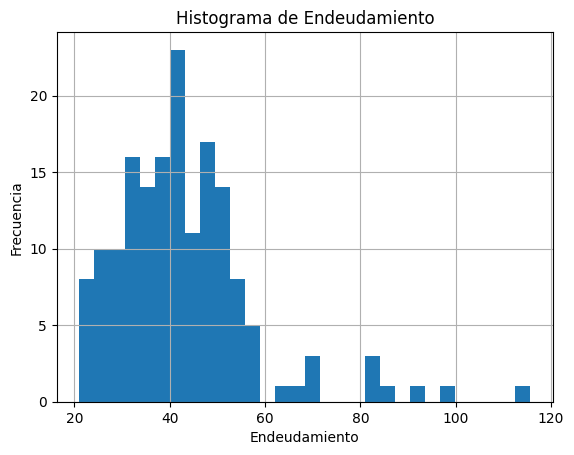

In [19]:
#Histograma de "endeudamiento" del total de data
ax = data["endeudamiento"].hist(bins=30)

# (Opcional) etiquetas del gráfico
ax.set_title("Histograma de Endeudamiento")
ax.set_xlabel("Endeudamiento")
ax.set_ylabel("Frecuencia")

#El histrograma de todo el dataframe combinando ambas clases (social y media) indican que los niveles de endeudamiento se concentran entre 20% y 60%, mayor al 60% se le puede considerar un outlier.

Text(0, 0.5, 'Frecuencia')

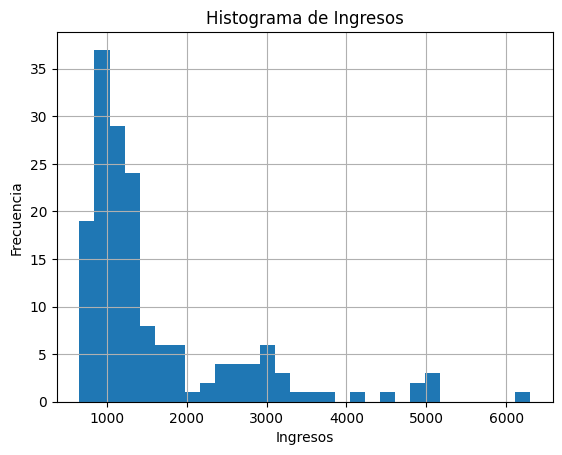

In [20]:
#Histograma de "ingresos" del total de data
ax = data["ingreso_$"].hist(bins=30)

# (Opcional) etiquetas del gráfico
ax.set_title("Histograma de Ingresos")
ax.set_xlabel("Ingresos")
ax.set_ylabel("Frecuencia")

#El histrograma de todo el dataframe combinando ambas clases (social y media) indican que los niveles de ingresos se concentran entre $500 y $3,000, mayor a $3,000 se le puede considerar un outlier.

Text(0, 0.5, 'Frecuencia')

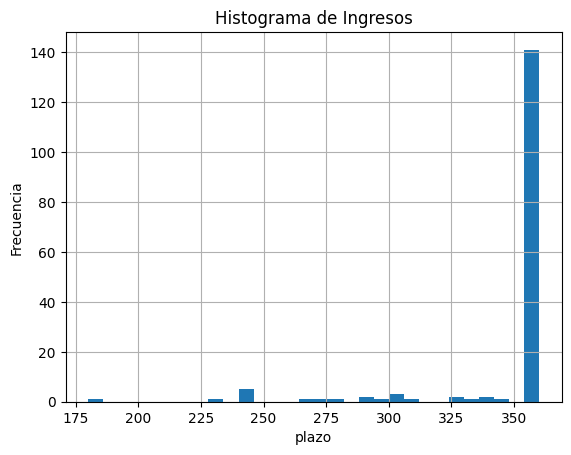

In [21]:
#Histograma de "plazo" del total de data
ax = data["plazo"].hist(bins=30)

# (Opcional) etiquetas del gráfico
ax.set_title("Histograma de Ingresos")
ax.set_xlabel("plazo")
ax.set_ylabel("Frecuencia")

#El histrograma de todo el dataframe combinando ambas clases (social y media) indican que el plazo se concentra fuertemente en un plazo de 360 meses.